## Notebook Convention

Build a single combined Kerchunk manifest for all files with
`grib2io.kerchunk.ReferenceGenerator`, then open it lazily with the standard
`zarr` engine via an `fsspec` reference filesystem.

For many files this is far faster than `xr.open_mfdataset(..., engine="grib2io")`:
`ReferenceGenerator` scans each file's `.idx` sidecar in a thread pool (header
bytes only) and concatenates along `valid_time` in one pass, avoiding the Dask
worker dispatch and `s3fs` dataset pickling that stalls `open_mfdataset` at scale.


In [5]:
import json
import time
import warnings

import fsspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import grib2io
from grib2io.kerchunk import ReferenceGenerator

warnings.filterwarnings("ignore")


# Optional notebook-only dependency for future VirtualiZarr/object-store workflows.
try:
    from obstore.store import S3Store
    from obspec_utils.registry import ObjectStoreRegistry

    OBSTORE_AVAILABLE = True
    print("Optional obstore dependencies are available.")
except ImportError:
    OBSTORE_AVAILABLE = False


Optional obstore dependencies are available.


In [6]:
BUCKET = "noaa-gefs-pds"
YEAR = "2025"  # any YYYY present in the bucket
GRID = "0p25"  # 0.25-degree global grid
CYCLE = "00"  # 00Z analysis
FORECAST = "f000"  # analysis hour (zero-lead)

# Keep this minimal; grib2io provides default timeout/retry behavior.
storage_options = {"anon": True}

# Column-integrated aerosol fields live on the "entire atmosphere" surface
# (typeOfFirstFixedSurface=10). We select the single variable of interest below.
AOD_FILTERS = {"typeOfFirstFixedSurface": 10}
AOD_VAR = "totAOD550"  # total aerosol optical depth at 550 nm

# Build URLs for the selected year.
year_start = pd.to_datetime(f"{YEAR}-01-01")
year_end = pd.to_datetime(f"{YEAR}-12-31")
dates = pd.date_range(year_start, year_end, freq="D")
PERIOD_LABEL = YEAR
urls = [f"s3://{BUCKET}/gefs.{d.strftime('%Y%m%d')}/{CYCLE}/chem/pgrb2ap25/gefs.chem.t{CYCLE}z.a2d_0p25.{FORECAST}.grib2" for d in dates]
print(f"Period: {PERIOD_LABEL}  ({len(urls)} files)")
print("First:", urls[0])
print("Last: ", urls[-1])


Period: 2025  (365 files)
First: s3://noaa-gefs-pds/gefs.20250101/00/chem/pgrb2ap25/gefs.chem.t00z.a2d_0p25.f000.grib2
Last:  s3://noaa-gefs-pds/gefs.20251231/00/chem/pgrb2ap25/gefs.chem.t00z.a2d_0p25.f000.grib2


In [7]:
# Verify: a single file builds a manifest and opens in a few seconds.
t0 = time.perf_counter()
gen_sample = ReferenceGenerator(urls[0], filters=AOD_FILTERS, storage_options=storage_options)
manifest_sample = gen_sample.generate()

sample_manifest_path = "gefs_aod_sample_manifest.json"
with open(sample_manifest_path, "w") as f:
    json.dump(manifest_sample, f)

fs_sample = fsspec.filesystem(
    "reference",
    fo=sample_manifest_path,
    asynchronous=True,
    remote_options={"anon": True, "asynchronous": True},
)
ds_sample = xr.open_dataset(fs_sample.get_mapper(""), engine="zarr", consolidated=False)
print(f"Opened in {time.perf_counter() - t0:.1f}s")
print(ds_sample)


Opened in 0.4s
<xarray.Dataset> Size: 129MB
Dimensions:            (valid_time: 1, entire_atmosphere: 1, y: 721, x: 1440)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 8B 2025-01-01
  * entire_atmosphere  (entire_atmosphere) float64 8B nan
    latitude           (y, x) float64 8MB ...
    longitude          (y, x) float64 8MB ...
Dimensions without coordinates: y, x
Data variables: (12/27)
    totAOD340          (valid_time, entire_atmosphere, y, x) float32 4MB ...
    totAsy340          (valid_time, entire_atmosphere, y, x) float32 4MB ...
    totSSA340          (valid_time, entire_atmosphere, y, x) float32 4MB ...
    totAOD440          (valid_time, entire_atmosphere, y, x) float32 4MB ...
    totAOD550          (valid_time, entire_atmosphere, y, x) float32 4MB ...
    totScatAOD550      (valid_time, entire_atmosphere, y, x) float32 4MB ...
    ...                 ...
    tot_pm25_colmd     (valid_time, entire_atmosphere, y, x) float32 4MB ...
    du_pm25_colmd     

In [8]:
# Build ONE combined manifest for all files. max_workers uses a thread pool
# to scan the .idx sidecars concurrently (header bytes only, no payloads),
# concatenating along valid_time in a single pass.
t0 = time.perf_counter()
gen_year = ReferenceGenerator(
    urls,
    filters=AOD_FILTERS,
    storage_options=storage_options,
    max_workers=16,
)
manifest_year = gen_year.generate()
print(f"Built manifest for {len(urls)} files in {time.perf_counter() - t0:.2f}s")

# Persist and open the combined manifest as a single lazy dataset.
year_manifest_path = "gefs_aod_year_manifest.json"
with open(year_manifest_path, "w") as f:
    json.dump(manifest_year, f)

fs_year = fsspec.filesystem(
    "reference",
    fo=year_manifest_path,
    asynchronous=True,
    remote_options={"anon": True, "asynchronous": True},
)
ds = xr.open_dataset(fs_year.get_mapper(""), engine="zarr", consolidated=False)
print("dims:", dict(ds.sizes))
print("valid_time:", str(ds.valid_time.values[0]), "->", str(ds.valid_time.values[-1]))
print("variables (sample):", list(ds.data_vars)[:12])
ds


Built manifest for 365 files in 1.86s
dims: {'valid_time': 365, 'entire_atmosphere': 1, 'y': 721, 'x': 1440}
valid_time: 2025-01-01T00:00:00.000000000 -> 2025-12-31T00:00:00.000000000
variables (sample): ['totAOD340', 'totAsy340', 'totSSA340', 'totAOD440', 'totAOD550', 'totScatAOD550', 'duAOD550', 'duScatAOD550', 'ssAOD550', 'ssScatAOD550', 'so4AOD550', 'so4ScatAOD550']


<xarray.Dataset> Size: 41GB
Dimensions:            (valid_time: 365, entire_atmosphere: 1, y: 721, x: 1440)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 3kB 2025-01-01 ... 2025-12-31
  * entire_atmosphere  (entire_atmosphere) float64 8B nan
    latitude           (y, x) float64 8MB ...
    longitude          (y, x) float64 8MB ...
Dimensions without coordinates: y, x
Data variables: (12/27)
    totAOD340          (valid_time, entire_atmosphere, y, x) float32 2GB ...
    totAsy340          (valid_time, entire_atmosphere, y, x) float32 2GB ...
    totSSA340          (valid_time, entire_atmosphere, y, x) float32 2GB ...
    totAOD440          (valid_time, entire_atmosphere, y, x) float32 2GB ...
    totAOD550          (valid_time, entire_atmosphere, y, x) float32 2GB ...
    totScatAOD550      (valid_time, entire_atmosphere, y, x) float32 2GB ...
    ...                 ...
    tot_pm25_colmd     (valid_time, entire_atmosphere, y, x) float32 2GB ...
    du_pm25_colmd      (valid_time, entire_atmosphere, y, x) float32 2GB ...
    ss_pm25_colmd      (valid_time, entire_atmosphere, y, x) float32 2GB ...
    bc_pm236_colmd     (valid_time, entire_atmosphere, y, x) float32 2GB ...
    om_pm424_colmd     (valid_time, entire_atmosphere, y, x) float32 2GB ...
    so4_pm25_colmd     (valid_time, entire_atmosphere, y, x) float32 2GB ...

Computing annual mean AOD550 ...


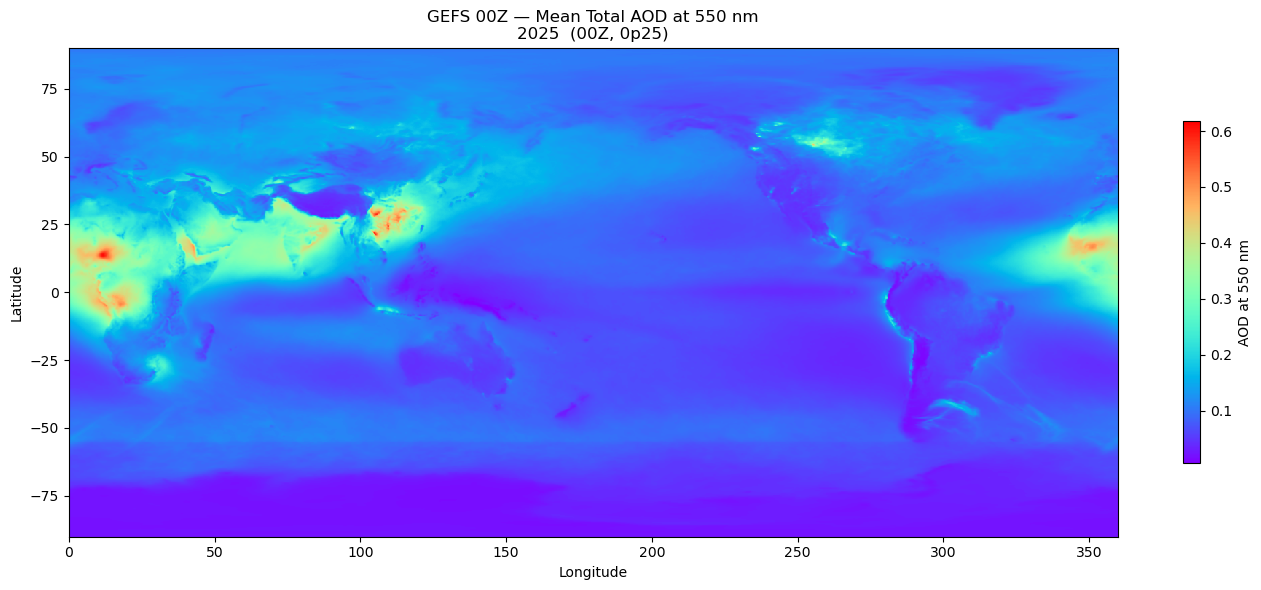

In [9]:
print("Computing annual mean AOD550 ...")

if AOD_VAR not in ds.data_vars:
    print(f"Variable {AOD_VAR!r} is not present in ds.")
    print(f"Available variables: {list(ds.data_vars)}")
    print("valid_time size:", ds.sizes.get("valid_time", 0))
else:
    # Stays lazy until .compute(); only the bytes needed are fetched from S3.
    aod_mean = ds[AOD_VAR].mean("valid_time").compute()

    lats = aod_mean.coords.get("latitude", aod_mean.coords.get("y", None))
    lons = aod_mean.coords.get("longitude", aod_mean.coords.get("x", None))

    fig, ax = plt.subplots(figsize=(14, 6))
    if lats is not None and lons is not None:
        pcm = ax.pcolormesh(lons, lats, aod_mean.squeeze(), cmap="rainbow", shading="auto")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    else:
        pcm = ax.imshow(aod_mean.squeeze(), origin="upper", cmap="rainbow", aspect="auto")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")

    plt.colorbar(pcm, ax=ax, label="AOD at 550 nm", shrink=0.7)
    ax.set_title(f"GEFS 00Z — Mean Total AOD at 550 nm\n{PERIOD_LABEL}  (00Z, {GRID})")
    plt.tight_layout()
    plt.show()
